# Training and Fine-Tuning BERT for Classification
## Classfying Goodreads Reviews By Book Genre

By Maria Antoniak, Melanie Walsh, and the [AI for Humanists](https://aiforhumanists.com/) Team

Updated: 2024-11-05
<br></br>

This notebook will demonstrate how users can train and fine-tune a BERT model for classification with the popular HuggingFace `transformers` Python library.

We will fine-tune a BERT model on Goodreads reviews from the [UCSD Book Graph](https://mengtingwan.github.io/data/goodreads.html) with the goal of predicting the genre of the book being reviewed. The genres include:
- poetry
- comics & graphic
- fantasy & paranormal
- history & biography
- mystery, thriller, & crime
- romance
- young adult  

**Basic steps involved in using BERT and HuggingFace:**
1. Divide your data into training and test sets.
2. Encode your data into a format BERT will understand.
3. Combine your data and labels into datset objects.
4. Load the pre-trained BERT model.
5. Fine-tune the model using your training data.
6. Predict new labels and evaluate performance on your test data.



<br><br>

## **Import necessary Python libraries and modules**

First, we will import necessary Python libraries and modules. These include as `gdown`, for downloading large files from Google Drive (where we will get our UCSD Goodreads reviews), as well as scikit-learn (`sklearn`) and PyTorch (`torch`), for various machine learning tools.

In [18]:
!pip3 install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 81.6 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 100.2 MB/s eta 0:00:0000:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [3]:
# Basic Python modules
from collections import defaultdict
import random
import pickle

# For downloading large files from Google Drive
# https://github.com/wkentaro/gdown
import gdown

# For working with gzip files
# https://docs.python.org/3/library/gzip.html
import gzip

# For working with JSON files
import json

# For data manipulation and analysis
import pandas as pd
import numpy as np

# For machine learning tools and evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# For deep learning
# https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html
import torch

# For plotting and data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
sns.set(style='ticks', font_scale=1.2)

The HuggingFace [`transformers` Python library](https://huggingface.co/transformers/installation.html) is included in Colab by default now, so we do not need to install it (but this is how you would install it with `pip`).

From `transformers`, we will import modules for `DistilBert`, a *distilled* or smaller version of a BERT model that runs more quickly and uses less computing power. This makes it ideal for those just getting started with BERT.

In [4]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

<br><br>

## **Set parameters and file paths**

In [5]:
# This is the name of the BERT model that we want to use.
# We're using DistilBERT to save space (it's a distilled version of the full BERT model),
# and we're going to use the cased (vs uncased) version.
model_name = 'distilbert-base-cased'

# This is the name of the program management system for NVIDIA GPUs. We're going to send our code here.
device_name = 'cuda'

# This is the maximum number of tokens in any document sent to BERT.
max_length = 512

# This is the name of the directory where we'll save our model. You can name it whatever you want.
cached_model_directory_name = 'distilbert-reviews-genres'

<br><br>

## **Load and sample Goodreads data**

In this cell, we create a Python dictionary with each genre and the link to the corresponding UCSD Goodreads review data for that genre.

*If you manually click on any of the URLs, you will be able to download the data for that genre. For example, here's the link for poetry: https://datarepo.eng.ucsd.edu/mcauley_group/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz*

In [6]:
# This is where our target data is hosted on the web. You only need these paths for the book review dataset.

# Source: https://mengtingwan.github.io/data/goodreads.html#datasets

genre_url_dict = {'poetry':                 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz',
                  'children':               'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_children.json.gz',
                  'comics_graphic':         'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_comics_graphic.json.gz',
                  'fantasy_paranormal':     'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_fantasy_paranormal.json.gz',
                  'history_biography':      'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_history_biography.json.gz',
                  'mystery_thriller_crime': 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_mystery_thriller_crime.json.gz',
                  'romance':                'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_romance.json.gz',
                  'young_adult':            'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_young_adult.json.gz'}

Next we loop through this dictionary and use `gdown` to download the Goodreads review data for each genre from Google Drive.

Now we will load the first 100,000 reviews from each link and randomly sample 2,000 reviews.

In [8]:
import os
import pickle
import requests
import gzip
import json
import random

# Stream reviews from URL and collect a subset
def load_reviews(url, head=10000, sample_size=2000):
    reviews = []
    count = 0

    response = requests.get(url, stream=True)
    print(response)

    with gzip.open(response.raw, 'rt', encoding='utf-8') as file:
        for line in file:
            d = json.loads(line)
            reviews.append(d['review_text'])
            count += 1

            # Stop if we have reached the limit
            if head is not None and count >= head:
                break

    # Return random sample of reviews
    return random.sample(reviews, min(sample_size, len(reviews)))


# PKL file path
pkl_file = "/kaggle/input/datasets/ashwanig20ait2022/genre-review-dict/genre_reviews_dict.pickle"

# Reviews by genre
genre_reviews_dict = {}

# If offline PKL exists, load from it
if os.path.exists(pkl_file):

    print(f"Loading reviews from offline file: {pkl_file}")

    with open(pkl_file, "rb") as f:
        genre_reviews_dict = pickle.load(f)

# Else load from API and save offline copy
else:

    print("PKL file not found. Loading from API...")

    # Load reviews for each genre
    for genre, url in genre_url_dict.items():
        print(f'Loading reviews for genre: {genre}')

        genre_reviews_dict[genre] = load_reviews(
            url,
            head=10000,
            sample_size=2000
        )

    # Save offline copy
    with open(pkl_file, "wb") as f:
        pickle.dump(genre_reviews_dict, f)

    print(f"Saved reviews to {pkl_file}")

Loading reviews from offline file: /kaggle/input/datasets/ashwanig20ait2022/genre-review-dict/genre_reviews_dict.pickle


Let's preview a couple of the key-value pairs in `genre_reviews_dict`

In [10]:
 for _genre, _reviews in genre_reviews_dict.items():
    print(_genre)
    print(random.sample(_reviews, 1)[0])

poetry
..ry'` jda 
 :ktr m `jbny fyh hdwl ljml 
 lys lqdr 
 bqdr m hy khTwT 
 rsmnh 
 lttqT` lTrq wnltqy 
 Grybyn fy Gny@ 
 mn m`Tfy lmjnH 
 t`rfny lmTrt 
 mn tdhkr@ mTwy@ 
 fy jyb qlby 
 `l~ Trfh mTl` 
 qSyd@ `Sy@ 
 wHdk lrHl@ 
 wjhk lwjht 
 wHythm Hmm@ tHT 
 wTny 
 w'ynm yTyr lHmm 
 Tryqy 
 l~ 'yn y Hby 
 w'Gnytn `br@ 
 wlrD sTwn@ 
 mkswr@ tdwr? 
 ktf mlH@ 
 lkthr@ m tk' 
 `l~ DHkty Grb 
 `l~ dm`tk 
 '`lq l`lm 
 llmTr sm kthyr@ 
 'jmlh 
 m yml' kfWyW b`ynyk 
 kyf dwnm ydk 
 '`yd Hyk@ rwHy 
 lsn lSGr ldhyn 
 Tlqw Ty'r@ wrqy@ 
 dht Hrb 
 l`Sfyr fyn `jz@ 
 wlHy@ lyst Hbyb@ Hd 
 kyf Hynm nbky 
 l tnbt mn zhr? 
 lys lHb 
 sw~ mshjr@ fy 
 syr@ 
 bl Hqyb@ 
 'Hml nfsy lyk 
 Hyth lHy@ mftH 
 wqlby bwb mtfrq@ 
 l 'ryd lswk 
 'n y`thr `lyW 
 llHb lqdym 
 mftyH sjn 
 fy sryr lbyD 
 wlswd 
 Hlmt bk 
 mn t`by 
 `l~ yq@ qmySy 'Gfw 
 hl knt mk tshtqk? 
 hl 'Hbn 'Hd swn? 
 shq@ qdr 'qdmn 
 mn ymyn Hnnk 
 qhwty lbkr@ 
 wbtsmt ltwt 
 wl'n lqmyS ldhy 
 'hdytny 
 tlwyH@ kfn 
 'yh lHb 
 l t`raWn 'kthr 
 y

Here we use `pickle` to save this Python dictionary to a `.pickle` file so we can easily load it later.

*The `pickle` module allows you to save and load Python objects like lists and dictionaries.*

In [ ]:
pickle.dump(genre_reviews_dict, open('genre_reviews_dict.pickle', 'wb'))
# genre_reviews_dict = pickle.load(open('genre_reviews_dict.pickle', 'rb'))

<br><br>

## **Split the data into training and test sets**

When training a machine learning model, it is necessary to split your training data into two parts: a "training" set and a "test" set.

We will train our BERT model on the "training" set of Goodreads reviews and then we will evaluate how well it is performing by running it on the "test" set of Goodreads reviews that the model has never seen before.

Normally, to tune the hyperparameters, you should also create a "validation" set for tuning, and only use the "test" set once, at the end of all tuning. For simplicity, in this tutorial, we will only using a training and test set.

In [52]:
RAW_DATA_PATH = "/kaggle/input/datasets/ashwanig20ait2022/genre-review-dict/genre_reviews_dict.pickle"
PREPARED_DATA_PATH = "/kaggle/working/prepared_reviews.pkl"
MODEL_NAME = "distilbert-base-cased"
MAX_LENGTH = 512
HEAD = 10000
DOWNLOAD_SAMPLE_SIZE = 2000
REVIEWS_PER_GENRE = 1000
TRAIN_RATIO = 0.8
SEED = 42

def split_reviews(
    genre_reviews: dict[str, list[str]],
    reviews_per_genre: int,
    train_ratio: float,
) -> tuple[list[str], list[str], list[str], list[str]]:
    """Create train/test text and label lists from sampled genre reviews."""
    train_texts: list[str] = []
    train_labels: list[str] = []
    test_texts: list[str] = []
    test_labels: list[str] = []

    for genre, reviews in genre_reviews.items():
        sampled_reviews = random.sample(reviews, min(reviews_per_genre, len(reviews)))
        train_count = int(len(sampled_reviews) * train_ratio)

        train_texts.extend(sampled_reviews[:train_count])
        train_labels.extend([genre] * train_count)
        test_texts.extend(sampled_reviews[train_count:])
        test_labels.extend([genre] * (len(sampled_reviews) - train_count))

    return train_texts, train_labels, test_texts, test_labels


def prepare_data(genre_reviews) -> dict[str, object]:
    """Prepare tokenized data and label maps for training/evaluation."""
    from transformers import DistilBertTokenizerFast

    set_seed(SEED)
    raw_data_path = Path(RAW_DATA_PATH)
    output_path = Path(PREPARED_DATA_PATH)

    
    train_texts, train_labels, test_texts, test_labels = split_reviews(
        genre_reviews,
        reviews_per_genre=REVIEWS_PER_GENRE,
        train_ratio=TRAIN_RATIO,
    )

    label2id, id2label = build_label_maps(train_labels)
    tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
    train_encodings = tokenizer(
        train_texts,
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
    )
    test_encodings = tokenizer(
        test_texts,
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
    )

    prepared = {
        "model_name": MODEL_NAME,
        "max_length": MAX_LENGTH,
        "train_texts": train_texts,
        "train_labels": train_labels,
        "test_texts": test_texts,
        "test_labels": test_labels,
        "label2id": label2id,
        "id2label": id2label,
        "train_encodings": dict(train_encodings),
        "test_encodings": dict(test_encodings),
        "train_labels_encoded": [label2id[label] for label in train_labels],
        "test_labels_encoded": [label2id[label] for label in test_labels],
    }

    output_path.parent.mkdir(parents=True, exist_ok=True)
    with output_path.open("wb") as file:
        pickle.dump(prepared, file)

    print(f"Saved prepared data to {output_path}")
    print(f"Train examples: {len(train_texts)} | Test examples: {len(test_texts)}")
    return prepared

Show how many Goodreads reviews and labels we have in each category: 6400 training reviews, 6400 training labels (genres), 1600 test reviews, 1600 test labels (genre)

In [57]:
prepared_data = prepare_data(genre_reviews_dict)

Saved prepared data to /kaggle/working/prepared_reviews.pkl
Train examples: 6400 | Test examples: 1600


Here's an example of a training label and review:

<br><br>

## **Run a baseline model (logistic regression)**

Here we train and evaluate a simple TF-IDF baseline model using logistic regression.

We find better-than-random performance, even for a very small dataset. We'll see whether BERT can beat this good baseline!

In [59]:
train_texts = prepared_data['train_texts']
test_texts = prepared_data['test_texts']

In [62]:
train_texts[:2]

['<3 <3 <3 <3 <3 !',
 'While I generally enjoyed the epic poem formatting and the idea of modern day werewolves, I had a lot of problems with this book. The author imagines a world where women exist as tools to control a pack, to use their sex to control the men around them. There are a lack of female characters in this book, and the ones that do exist are merely there as a play thing of the men. The idea that human women would choose to become werewolves in order to lead that type of life is offensive and sexist. I believe his thought that modern women are willing to give up their current lives to be sex slaves is not only misogynistic but hurtful and brings women back hundreds of years.']

In [63]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

We train a logistic regression model from scikit-learn on the Goodreads training data, and then we use the trained model to make predictions on our Goodreads review test set.

In [64]:
model = LogisticRegression(max_iter=1000).fit(X_train, prepared_data['train_labels'])
predictions = model.predict(X_test)

We can use scikit-learn's `classification_report` function to evaluate how well the logistic regression model's predictions match up with the true labels for the Goodreads reviews.

Importantly, we can see that our average scores are above random performance (we have 8 classes, so random performance would be ~0.2).

In [65]:
print(classification_report(prepared_data['test_labels'], predictions))

                        precision    recall  f1-score   support

              children       0.64      0.59      0.62       200
        comics_graphic       0.76      0.70      0.73       200
    fantasy_paranormal       0.32      0.27      0.29       200
     history_biography       0.52      0.47      0.49       200
mystery_thriller_crime       0.53      0.54      0.53       200
                poetry       0.59      0.77      0.67       200
               romance       0.60      0.67      0.63       200
           young_adult       0.40      0.39      0.39       200

              accuracy                           0.55      1600
             macro avg       0.55      0.55      0.55      1600
          weighted avg       0.55      0.55      0.55      1600



<br><br>

## **Encode data for BERT**

We're going to transform our texts and labels into a format that BERT (via Huggingface and PyTorch) will understand. This is called *encoding* the data.

Here are the steps we need to follow:

1. The labels&mdash;in this case, Goodreads genres&mdash;need to be turned into integers rather than strings.

2. The texts&mdash;in this case, Goodreads reviews&mdash;need to be truncated if they're more than 512 tokens or padded if they're fewer than 512 tokens. The tokens, or words in the texts, also need to be separated into "word pieces" and matched to their embedding vectors.

3. We need to add special tokens to help BERT:

| BERT special token | Explanation |
| --------------| ---------|
| [CLS] | Start token of every document. |
| [SEP] | Separator between each sentence |
| [PAD] | Padding at the end of the document as many times as necessary, up to 512 tokens |
|  &#35;&#35; | Start of a "word piece" |




Here we will load `DistilBertTokenizerFast` from the HuggingFace library, which will do all the work of encoding the texts for us. The `tokenizer()` will break word tokens into word pieces, truncate to 512 tokens, and add padding and special BERT tokens.

In [66]:
import json
import random
from pathlib import Path
from typing import Any

import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score


def set_seed(seed: int) -> None:
    """Make sampling and model training more reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def build_label_maps(labels: list[str]) -> tuple[dict[str, int], dict[int, str]]:
    """Create stable label-to-id and id-to-label mappings."""
    unique_labels = sorted(set(labels))
    label2id = {label: index for index, label in enumerate(unique_labels)}
    id2label = {index: label for label, index in label2id.items()}
    return label2id, id2label


class ReviewDataset(torch.utils.data.Dataset):
    """PyTorch dataset wrapper for tokenized review texts and labels."""

    def __init__(self, encodings: dict[str, Any], labels: list[int]) -> None:
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        item = {key: torch.tensor(value[index]) for key, value in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[index])
        return item

    def __len__(self) -> int:
        return len(self.labels)


def compute_metrics(pred: Any) -> dict[str, float]:
    """Metrics callback used by HuggingFace Trainer."""
    labels = pred.label_ids
    predictions = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted", zero_division=0),
    }


In [72]:
import inspect
import os
import pickle
from pathlib import Path


PREPARED_DATA_PATH = "/kaggle/working/prepared_reviews.pkl"
MODEL_NAME = "distilbert-base-cased"
MODEL_OUTPUT_DIR = "distilbert-reviews-genres"
TRAINING_OUTPUT_DIR = "results/trainer"
LOGGING_DIR = "logs"
NUM_TRAIN_EPOCHS = 3
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
LEARNING_RATE = 3e-5
WARMUP_STEPS = 100
WEIGHT_DECAY = 0.01
LOGGING_STEPS = 50
EVAL_STRATEGY = "epoch"
SAVE_STRATEGY = "epoch"
SEED = 42
WANDB_PROJECT = "mlops-assignment2"
WANDB_RUN_NAME = "distilbert-run-1"
HF_REPO_ID = "Nlp0187/distilbert-goodreads-genres"


def load_prepared_data(path: str | Path) -> dict:
    with Path(path).open("rb") as file:
        return pickle.load(file)


def build_training_args():
    """Build TrainingArguments across transformers versions."""
    from transformers import TrainingArguments

    training_kwargs = {
        "output_dir": TRAINING_OUTPUT_DIR,
        "logging_dir": LOGGING_DIR,
        "num_train_epochs": NUM_TRAIN_EPOCHS,
        "per_device_train_batch_size": TRAIN_BATCH_SIZE,
        "per_device_eval_batch_size": EVAL_BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "warmup_steps": WARMUP_STEPS,
        "weight_decay": WEIGHT_DECAY,
        "logging_steps": LOGGING_STEPS,
        "save_strategy": SAVE_STRATEGY,
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1",
        "greater_is_better": True,
        "report_to": "wandb",
        "run_name": WANDB_RUN_NAME,
    }

    signature = inspect.signature(TrainingArguments.__init__)
    if "eval_strategy" in signature.parameters:
        training_kwargs["eval_strategy"] = EVAL_STRATEGY
    else:
        training_kwargs["evaluation_strategy"] = EVAL_STRATEGY

    return TrainingArguments(**training_kwargs)



<br><br>

## **Set the BERT fine-tuning parameters**

These are the arguments we'll set in the HuggingFace TrainingArguments objects, which we'll then pass to the HuggingFace Trainer object. There are many more possible arguments, but here we highlight the basics and some common gotchas.

When training your own model, you should search over these parameters to find the best settings for your particular dataset. You should use a held-out set of validation data for this step.

| Parameter | Explanation |
|-----------| ------------|
| num_train_epochs | total number of training epochs (how many times to pass through the entire dataset; too much can cause overfitting) |
| per_device_train_batch_size | batch size per device during training |
| per_device_eval_batch_size |  batch size for evaluation |
|  warmup_steps |  number of warmup steps for learning rate scheduler (set lower because of small dataset size) |
| weight_decay | strength of weight decay (reduces size of weights, like regularization) |
| output_dir | output directory for the fine-tuned model and configuration files |
| logging_dir | directory for storing logs |
| logging_steps | how often to print logging output (so that we can stop training early if the loss isn't going down) |
| evaluation_strategy | evaluate while training so that we can see the accuracy going up |

In [68]:
from kaggle_secrets import UserSecretsClient
import os

user_secrets = UserSecretsClient()
os.environ['HF_TOKEN'] = user_secrets.get_secret("HF_TOKEN")
os.environ['WANDB_API_KEY'] = user_secrets.get_secret("WANDB_API_KEY")

<br><br>

## **Fine-tune the BERT model**

Then we create a HuggingFace `Trainer` object using the `TrainingArguments` object that we created above. We also send our `compute_metrics` function to the `Trainer` object, along with our test and train datasets.

**Note:** This is what we've been aiming for this whole time! All the work of tokenizing, creating datasets, and setting the training arguments was for this cell.

Time to finally fine-tune!

Be patient; if you've set everything in Colab to use GPUs, then it should only take a minute or two to run, but if you're running on CPU, it can take hours.

After every 10 steps (as we specified in the TrainingArguments object), the trainer will output the current state of the model, including the training loss, validation ("test") loss, and accuracy (from our `compute_metrics` function).

You should see the loss going down and the accuracy going up. If instead they are staying the same or oscillating, you probably need to change the fine-tuning parameters.

In [73]:
def train() -> Trainer:
    import wandb
    from huggingface_hub import login
    from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
    from transformers import Trainer

    set_seed(SEED)

    data = load_prepared_data(PREPARED_DATA_PATH)
    label2id = data["label2id"]
    id2label = {int(key): value for key, value in data["id2label"].items()}

    train_dataset = ReviewDataset(data["train_encodings"], data["train_labels_encoded"])
    test_dataset = ReviewDataset(data["test_encodings"], data["test_labels_encoded"])

    model = DistilBertForSequenceClassification.from_pretrained(
        data.get("model_name", MODEL_NAME),
        num_labels=len(label2id),
        label2id=label2id,
        id2label=id2label,
    )
    training_args = build_training_args()

    wandb.init(
        project=WANDB_PROJECT,
        name=WANDB_RUN_NAME,
        config={
            "model": data.get("model_name", MODEL_NAME),
            "epochs": NUM_TRAIN_EPOCHS,
            "batch_size": TRAIN_BATCH_SIZE,
            "eval_batch_size": EVAL_BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "max_length": data.get("max_length"),
            "dataset": "UCSD Goodreads",
            "train_examples": len(train_dataset),
            "test_examples": len(test_dataset),
        },
    )

    try:
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=test_dataset,
            compute_metrics=compute_metrics,
        )

        trainer.train()
        trainer.save_model(MODEL_OUTPUT_DIR)

        tokenizer = DistilBertTokenizerFast.from_pretrained(data.get("model_name", MODEL_NAME))
        tokenizer.save_pretrained(MODEL_OUTPUT_DIR)

        hf_token = os.getenv("HF_TOKEN")
        if hf_token:
            login(token=hf_token)
            trainer.model.push_to_hub(HF_REPO_ID, private=False)
            tokenizer.push_to_hub(HF_REPO_ID, private=False)
            hf_model_url = f"https://huggingface.co/{HF_REPO_ID}"
            wandb.run.summary["huggingface_model"] = hf_model_url
            print(f"Pushed model and tokenizer to {hf_model_url}")
        else:
            print("HF_TOKEN not set. Saved locally but skipped Hugging Face upload.")

        print(f"Saved fine-tuned model to {MODEL_OUTPUT_DIR}")
        return trainer
    finally:
        wandb.finish()

In [74]:
#train the model:
train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` /

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.650298,2.542173,0.555000,0.547810
2,2.153273,2.351805,0.569375,0.568888
3,1.711724,2.363139,0.585625,0.582938


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Pushed model and tokenizer to https://huggingface.co/Nlp0187/distilbert-goodreads-genres
Saved fine-tuned model to distilbert-reviews-genres


eval/accuracy,▁▄█
eval/f1,▁▅█
eval/loss,█▁▁
eval/runtime,▂▁█
eval/samples_per_second,▇█▁
eval/steps_per_second,▆█▁
train/epoch,▁▂▂▃▃▄▄▅▅▅▆▇▇███
train/global_step,▁▂▂▃▃▄▄▅▅▅▆▇▇███
train/grad_norm,▁▄█▄▇▅▆▆▅▆▃▄
train/learning_rate,▄█▇▇▆▅▅▄▃▂▂▁
+1,...


<br><br>

## **Evaluate fine-tuned model**

The following function of the `Trainer` object will run the built-in evaluation, including our `compute_metrics` function.

In [78]:
import csv
import pickle
from pathlib import Path

from sklearn.metrics import classification_report


PREPARED_DATA_PATH = "/kaggle/working/prepared_reviews.pkl"
MODEL_OUTPUT_DIR = "distilbert-reviews-genres"
RESULTS_DIR = "results"
WANDB_PROJECT = "mlops-assignment2"
WANDB_RUN_NAME = "distilbert-run-1"


def load_prepared_data(path: str | Path) -> dict:
    with Path(path).open("rb") as file:
        return pickle.load(file)


def save_json(data: Any, path: str | Path) -> None:
    output_path = Path(path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with output_path.open("w", encoding="utf-8") as file:
        json.dump(data, file, indent=2)
        
def save_predictions(
    path: str | Path,
    texts: list[str],
    true_labels: list[str],
    predicted_labels: list[str],
) -> None:
    output_path = Path(path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with output_path.open("w", encoding="utf-8", newline="") as file:
        writer = csv.DictWriter(
            file,
            fieldnames=["true_label", "predicted_label", "review_text"],
        )
        writer.writeheader()
        for true_label, predicted_label, text in zip(true_labels, predicted_labels, texts):
            writer.writerow(
                {
                    "true_label": true_label,
                    "predicted_label": predicted_label,
                    "review_text": text,
                }
            )


def evaluate() -> dict:
    import wandb
    from transformers import DistilBertForSequenceClassification, Trainer

    data = load_prepared_data(PREPARED_DATA_PATH)
    id2label = {int(key): value for key, value in data["id2label"].items()}
    test_dataset = ReviewDataset(data["test_encodings"], data["test_labels_encoded"])

    model = DistilBertForSequenceClassification.from_pretrained(MODEL_OUTPUT_DIR)
    trainer = Trainer(model=model, compute_metrics=compute_metrics)

    wandb.init(
        project=WANDB_PROJECT,
        name=f"{WANDB_RUN_NAME}-eval",
        job_type="evaluation",
        config={
            "model_dir": MODEL_OUTPUT_DIR,
            "data_path": PREPARED_DATA_PATH,
            "dataset": "UCSD Goodreads",
        },
    )

    try:
        metrics = trainer.evaluate(test_dataset)
        prediction_output = trainer.predict(test_dataset)
        predicted_ids = prediction_output.predictions.argmax(-1).flatten().tolist()
        predicted_labels = [id2label[predicted_id] for predicted_id in predicted_ids]

        report = classification_report(
            data["test_labels"],
            predicted_labels,
            output_dict=True,
            zero_division=0,
        )
        text_report = classification_report(
            data["test_labels"],
            predicted_labels,
            zero_division=0,
        )

        metrics_output = f"{RESULTS_DIR}/eval_metrics.json"
        report_output = f"{RESULTS_DIR}/classification_report.json"
        predictions_output = f"{RESULTS_DIR}/predictions.csv"

        save_json(metrics, metrics_output)
        save_json(report, report_output)
        save_predictions(
            predictions_output,
            data["test_texts"],
            data["test_labels"],
            predicted_labels,
        )

        wandb.log(
            {
                "final/loss": metrics.get("eval_loss"),
                "final/accuracy": metrics.get("eval_accuracy"),
                "final/f1": metrics.get("eval_f1"),
            }
        )
        artifact = wandb.Artifact("eval-report", type="evaluation")
        artifact.add_file(report_output)
        wandb.log_artifact(artifact)

        print(metrics)
        print(text_report)
        print(f"Saved metrics to {metrics_output}")
        print(f"Saved classification report to {report_output}")
        print(f"Saved predictions to {predictions_output}")
        return metrics
    finally:
        wandb.finish()

But we might want to do more fine-grained analysis of the model, so we extract the predicted labels.

In [79]:
evaluate()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.3631391525268555, 'eval_accuracy': 0.585625, 'eval_f1': 0.5829382608247748, 'eval_runtime': 14.6591, 'eval_samples_per_second': 109.147, 'eval_steps_per_second': 6.822}
                        precision    recall  f1-score   support

              children       0.66      0.60      0.63       200
        comics_graphic       0.85      0.75      0.80       200
    fantasy_paranormal       0.35      0.35      0.35       200
     history_biography       0.56      0.55      0.55       200
mystery_thriller_crime       0.56      0.65      0.60       200
                poetry       0.73      0.84      0.78       200
               romance       0.59      0.64      0.61       200
           young_adult       0.36      0.30      0.33       200

              accuracy                           0.59      1600
             macro avg       0.58      0.59      0.58      1600
          weighted avg       0.58      0.59      0.58      1600

Saved metrics to results/eval_metrics.json
S

final/accuracy,▁
final/f1,▁
final/loss,▁
final/accuracy,0.58562
final/f1,0.58294
final/loss,2.36314


{'eval_loss': 2.3631391525268555,
 'eval_accuracy': 0.585625,
 'eval_f1': 0.5829382608247748,
 'eval_runtime': 14.6591,
 'eval_samples_per_second': 109.147,
 'eval_steps_per_second': 6.822}

<br><br>

## **Pull out correct and incorrect classifications for examination**

Let's use our predicted labels for some analysis!

Now that we've fine-tuned and pulled out our predicted labels, the BERT part of this tutorial is done. You can now use the predicted labels in the same way you would use any set of predicted labels from any classification model. We'll show some examples here.

First, let's print out some example predictions that were correct.

In [80]:
data = load_prepared_data(PREPARED_DATA_PATH)
id2label = {int(key): value for key, value in data["id2label"].items()}
test_dataset = ReviewDataset(data["test_encodings"], data["test_labels_encoded"])
prediction_output = trainer.predict(test_dataset)
predicted_ids = prediction_output.predictions.argmax(-1).flatten().tolist()
predicted_labels = [id2label[predicted_id] for predicted_id in predicted_ids]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [85]:
test_labels = data['test_labels']
text_tests = data['test_texts']

In [93]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 100):
  if _true_label == _predicted_label:
    print('TRUE LABEL:', _true_label)
    print('PREDICTED LABEL:', _predicted_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

TRUE LABEL: history_biography
PREDICTED LABEL: history_biography
REVIEW TEXT: re-read :) ...

TRUE LABEL: history_biography
PREDICTED LABEL: history_biography
REVIEW TEXT: Great book of wonderful essays. Lots of fun for those interested in history as well as those interes ...

TRUE LABEL: fantasy_paranormal
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: Ms MOning hit it out of the ballpark with this one! Her highland Alphas are unforgettable. PUtting t ...

TRUE LABEL: comics_graphic
PREDICTED LABEL: comics_graphic
REVIEW TEXT: Same exact problems as "Skywalker Strikes." But Vader has always been the most compelling character  ...

TRUE LABEL: history_biography
PREDICTED LABEL: history_biography
REVIEW TEXT: What a glorious discovery. I bought this book a few months ago because the Kindle version was cheap  ...

TRUE LABEL: comics_graphic
PREDICTED LABEL: comics_graphic
REVIEW TEXT: Strange, strange book...and I tend to like strange books. This one didn't quite completely do it for .

In [86]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label != _predicted_label:
    print('TRUE LABEL:', _true_label)
    print('PREDICTED LABEL:', _predicted_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

TRUE LABEL: fantasy_paranormal
PREDICTED LABEL: history_biography
REVIEW TEXT: This was a fascinating and engaging look at "the future" through the eyes of the past. Blind to the  ...

TRUE LABEL: comics_graphic
PREDICTED LABEL: mystery_thriller_crime
REVIEW TEXT: Greatartwork. I am rooting for them! Gives out detailed info about making manga. ...

TRUE LABEL: children
PREDICTED LABEL: young_adult
REVIEW TEXT: Possibly the funniest thing I have ever read. ...

TRUE LABEL: comics_graphic
PREDICTED LABEL: romance
REVIEW TEXT: This story was too fast, too small and too broad. I didn't have a chance to become attached to the c ...

TRUE LABEL: young_adult
PREDICTED LABEL: poetry
REVIEW TEXT: Okay. 
 That's about all I can say about this book. I wasn't bowled over by the story line. It felt  ...

TRUE LABEL: fantasy_paranormal
PREDICTED LABEL: children
REVIEW TEXT: 4.5 
 Ouch my heart. ...

TRUE LABEL: children
PREDICTED LABEL: young_adult
REVIEW TEXT: I enjoyed reading these carefully-writ

Finally, let's create some heatmaps to examine misclassification patterns. We could use these patterns to think about similarities and differences between genres, according to book reviewers.

In [87]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

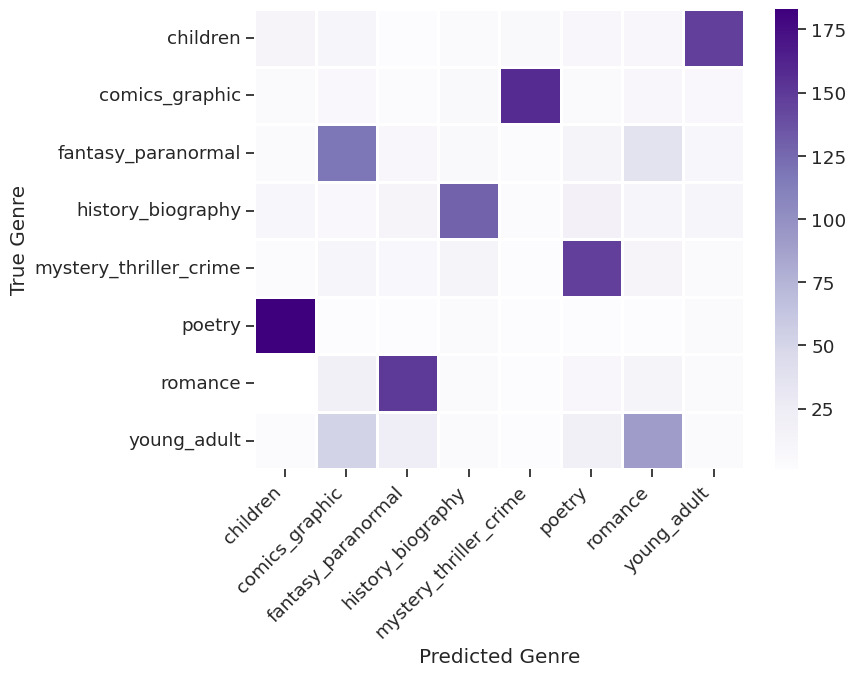

In [88]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Looks good! We can see that overall, our model is assigning the correct labels for each genre.

Now, let's remove the diagonal from the plot to highlight the misclassifications.

In [89]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  if _true_label != _predicted_label: # Remove the diagonal to highlight misclassifications
    genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

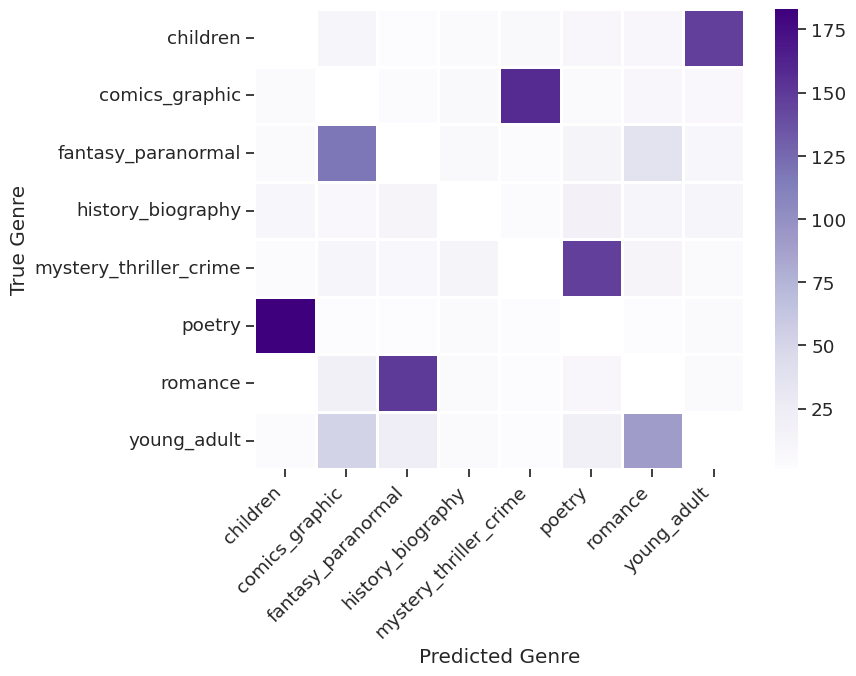

In [90]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

There's much more you can do with your own dataset and labels! Classification can be used to apply a small set of labels across a big dataset; to explore misclassifications to better understand users; and much more! We hope you'll use this tutorial in all kinds of creative ways.